# ReAct

1. act : Le modèle appelle une tool spécifique
2. observe : la sortie de la tool retounre au modèle
3. reason : le raisonnement du modèle sur la sortie de la tool va décider la suite

In [29]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
import requests # Permet de faire des requêtes HTTP
import feedparser # L’API arXiv retourne du XML Atom. feedparser transforme le XML compliqué en objets Python simples

url = "https://export.arxiv.org/api/query" # endpoint officiel de l’API arXiv

params = {
    "search_query": "all:Attention Is All You Need",
    "start": 0,
    "max_results": 2
}

response = requests.get(url, params=params) # envoie la requête et récupère la réponse du serveur

feed = feedparser.parse(response.text)

for entry in feed.entries:
    print(entry.title)
    print(entry.summary[:500])

Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a
"All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponential growth ($R^2$ > 0.994) following t

In [3]:
def search_arxiv_papers(query: str) -> str:
    """Search scientific papers on arxiv."""

    import requests
    import feedparser

    url = "https://export.arxiv.org/api/query"

    response = requests.get(
        url,
        params={
            "search_query": f"all:{query}",
            "start": 0,
            "max_results": 2
        }
    )

    feed = feedparser.parse(response.text)

    if not feed.entries:
        return "No paper found"

    results = []

    for paper in feed.entries[:2]:
        results.append(
            f"""
Title: {paper.title}

Summary:
{paper.summary[:500]}
"""
        )

    return "\n\n".join(results)

In [4]:
import wikipedia.wikipedia as wp

wp.API_URL = "https://en.wikipedia.org/w/api.php"
wp.USER_AGENT = "NicolasAgenticAI/1.0 (nicolas.sales77@gmail.com)"

from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

api_wrapper = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500
)

wiki = WikipediaQueryRun(api_wrapper=api_wrapper)

print(wiki.invoke("What is machine learning?"))

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m


In [5]:
from dotenv import load_dotenv
load_dotenv()

import os

In [6]:
os.environ["LANGCHAIN_TRACING_V2"] = "True"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-agent"

In [7]:
# Custom function

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [8]:
# Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\nico_\AppData\Local\Temp\ipykernel_15356\3336424662.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("Provide me the 5 last AI news")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': 'AI in Action\n\nJune 3, 2026\n\n### Anthropic IPO filing marks AI maturing into enterprise utility\n\nAI Business Strategy\n\nJune 2, 2026\n\n#### Industries\n\n### Meta Business Agent drives AI-powered conversational commerce\n\nRetail & Logistics AI\n\nJune 4, 2026\n\n### Google folds Display Ads into AI-first Demand Gen platform\n\nMarketing AI\n\nMay 27, 2026\n\n### RingCentral adds Shopify, Calendly, and WhatsApp to AI Receptionist\n\nService Industry AI\n\nMay 8, 2026\n\n#### Deep Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### China’s AI just mapped its entire renewable energy grid. Here’s why the rest of the world should pay attention\n\nEnvironment & Sustainability\n\nMay 22, 2026 [...] Inside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and t

In [10]:
tools = [search_arxiv_papers,wiki,tavily,multiply,add,divide]

In [11]:

from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("Hello")

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.011025539, 'completion_tokens_details': None, 'prompt_time': 0.001908102, 'prompt_tokens_details': None, 'queue_time': 0.044295455, 'total_time': 0.012933641}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ead7d-188b-7c11-8880-b8654ffdeee5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [12]:
llm_with_tools = llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage

llm_with_tools.invoke([HumanMessage(content=f"What is th recent AI new?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Recent AI news'},
  'id': 'g1qrt1dc7',
  'type': 'tool_call'}]

In [14]:
llm_with_tools.invoke([HumanMessage(content=f"combien font 1 + 1?")]).tool_calls

[{'name': 'add',
  'args': {'a': 1, 'b': 1},
  'id': 'b2g17qka7',
  'type': 'tool_call'}]

In [16]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages # Pour fusionner 2 listes de messages
from typing import Annotated

In [17]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

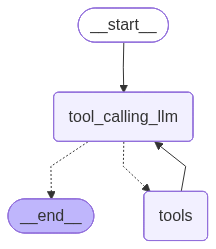

In [19]:
from IPython.display import Image, display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # Si le dernier message (result) de l'assistant est un appel d'outil -> conditions de l'outils sont transmises à l'outils
    # Si le dernier message (result) de l'assistant n'est pas un appel d'outil -> tools_condition transmis à END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
messages = graph.invoke({"messages":HumanMessage(content="Provide me the top ten recent AI news for March 3rd 2025, add 5 plus 5 and then multiply by 10")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me the top ten recent AI news for March 3rd 2025, add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (9rgkqrc3q)
 Call ID: 9rgkqrc3q
  Args:
    query: top ten recent AI news March 3rd 2025
  add (hz81r91g2)
 Call ID: hz81r91g2
  Args:
    a: 5
    b: 5
  multiply (xpt6hfjrd)
 Call ID: xpt6hfjrd
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The 10 Biggest AI News Stories Of 2025", "url": "https://www.crn.com/news/ai/2025/the-10-biggest-ai-news-stories-of-2025", "content": "# The 10 Biggest AI News Stories Of 2025\n\nThe AI industry in 2025 saw big-money acquisitions, advancements in virtual assistants and agent orchestration, and new innovations in hardware.\n\nTechnological Iceberg a

In [37]:
messages = graph.invoke({"messages":HumanMessage(content="What is the machine learning")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (z7yaw7hg9)
 Call ID: z7yaw7hg9
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m
================================== Ai Message ==================================
Tool Calls:
  wikipedia (a9e69qnck)


## Agent Memory

Pour utilsier la mémoire, il vaut mieux changer de modèle

In [49]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

In [50]:
llm_with_tools = llm.bind_tools(tools)

In [54]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### MemorySaver

In [55]:
# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # Si le dernier message (result) de l'assistant est un appel d'outil -> conditions de l'outils sont transmises à l'outils
    # Si le dernier message (result) de l'assistant n'est pas un appel d'outil -> tools_condition transmis à END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

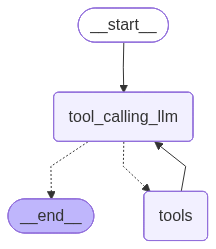

In [57]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [58]:
# Specify the thread (file)

config = {"configurable":{"thread_id":"1"}}

# Specify an input
messages = [HumanMessage(content="Add 15 and 25")]
messages = graph_memory.invoke({"messages":messages},config=config)

for m in messages["messages"]:
    m.pretty_print()


================================ Human Message =================================

Add 15 and 25
================================== Ai Message ==================================
Tool Calls:
  add (call_0cJ1j0TSkgNdtl5BzBaYRIYK)
 Call ID: call_0cJ1j0TSkgNdtl5BzBaYRIYK
  Args:
    a: 15
    b: 25
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================

The sum of 15 and 25 is 40.


In [59]:
messages = [HumanMessage(content="Add that number to 25")]
messages = graph_memory.invoke({"messages":messages},config=config)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 15 and 25
================================== Ai Message ==================================
Tool Calls:
  add (call_0cJ1j0TSkgNdtl5BzBaYRIYK)
 Call ID: call_0cJ1j0TSkgNdtl5BzBaYRIYK
  Args:
    a: 15
    b: 25
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================

The sum of 15 and 25 is 40.
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_kUEJR05fDoT42OabPT55e92i)
 Call ID: call_kUEJR05fDoT42OabPT55e92i
  Args:
    a: 40
    b: 25
================================= Tool Message =================================
Name: add

65
================================== Ai Message ==================================

Adding 40 to 25 give

In [60]:
messages = [HumanMessage(content="Then multiply by 2")]
messages = graph_memory.invoke({"messages":messages},config=config)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 15 and 25
================================== Ai Message ==================================
Tool Calls:
  add (call_0cJ1j0TSkgNdtl5BzBaYRIYK)
 Call ID: call_0cJ1j0TSkgNdtl5BzBaYRIYK
  Args:
    a: 15
    b: 25
================================= Tool Message =================================
Name: add

40
================================== Ai Message ==================================

The sum of 15 and 25 is 40.
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_kUEJR05fDoT42OabPT55e92i)
 Call ID: call_kUEJR05fDoT42OabPT55e92i
  Args:
    a: 40
    b: 25
================================= Tool Message =================================
Name: add

65
================================== Ai Message ==================================

Adding 40 to 25 give